<a href="https://colab.research.google.com/github/kherakriti-ai/Coffee-Sales-Analysis/blob/main/CoffeeSalesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving coffee_shop_sales.csv to coffee_shop_sales.csv


In [3]:
df = pd.read_csv('coffee_shop_sales.csv')

In [4]:
df.shape

(20000, 20)

In [5]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-null  bool   
 16  weat

In [6]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts)
print("\nTotal null values in the dataset:")
print(null_counts.sum())

Null values per column:
transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

Total null values in the dataset:
23769


### Handling Missing Values

Based on the null counts, I will perform the following actions:
- Drop rows where 'customer_gender', 'weather_condition', or 'temperature_c' are null.
- Fill missing values in 'customer_age_group' with its mode.
- Drop the 'holiday_name' column as it has a very high number of missing values and might not be useful for analysis.

### Verifying Changes

In [10]:
print(df.info())

null_counts_after_handling = df.isnull().sum()
print("\nNull values per column after handling:")
print(null_counts_after_handling)
print("\nTotal null values in the dataset after handling:")
print(null_counts_after_handling.sum())

<class 'pandas.core.frame.DataFrame'>
Index: 17994 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      17994 non-null  int64  
 1   timestamp           17994 non-null  object 
 2   store_id            17994 non-null  int64  
 3   city                17994 non-null  object 
 4   country             17994 non-null  object 
 5   store_type          17994 non-null  object 
 6   product_category    17994 non-null  object 
 7   product_name        17994 non-null  object 
 8   unit_price          17994 non-null  float64
 9   quantity            17994 non-null  int64  
 10  discount_applied    17994 non-null  bool   
 11  payment_method      17994 non-null  object 
 12  customer_id         17994 non-null  object 
 13  customer_age_group  17994 non-null  object 
 14  customer_gender     17994 non-null  object 
 15  loyalty_member      17994 non-null  bool   
 16  weather_c

### Box Plots for Numerical Variables

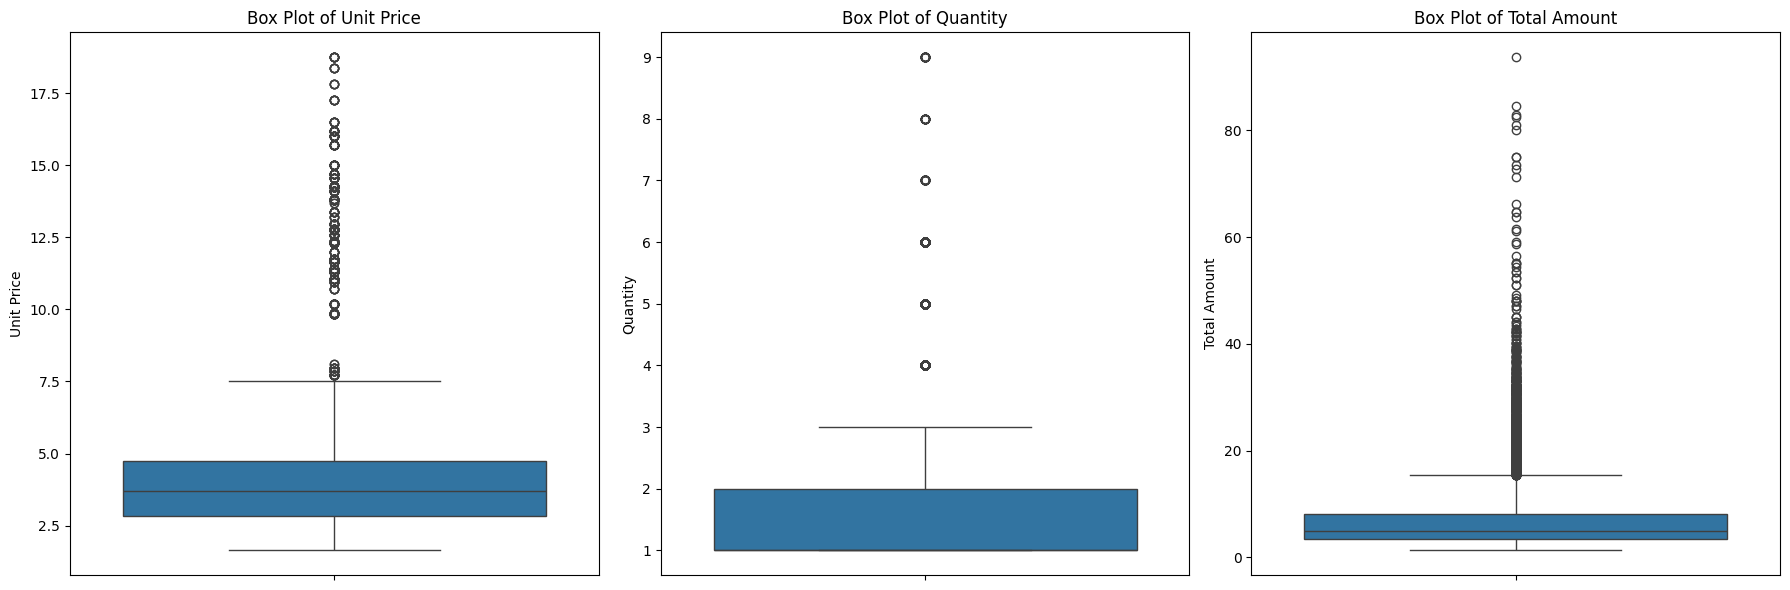

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(y=df['unit_price'], ax=axes[0])
axes[0].set_title('Box Plot of Unit Price')
axes[0].set_ylabel('Unit Price')

sns.boxplot(y=df['quantity'], ax=axes[1])
axes[1].set_title('Box Plot of Quantity')
axes[1].set_ylabel('Quantity')

sns.boxplot(y=df['total_amount'], ax=axes[2])
axes[2].set_title('Box Plot of Total Amount')
axes[2].set_ylabel('Total Amount')

plt.tight_layout()
plt.show()

### Number of Outliers Found

In [15]:
for column in ['unit_price', 'quantity', 'total_amount']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])
    print(f"Number of outliers in '{column}': {outliers_count}")

Number of outliers in 'unit_price': 537
Number of outliers in 'quantity': 1282
Number of outliers in 'total_amount': 1206


In [16]:
df[['unit_price','quantity','total_amount']].describe()

,unit_price,quantity,total_amount
count,17994.000000,17994.000000,17994.000000
mean,4.055694,1.713849,6.853302
std,1.991696,1.113360,5.958557
min,1.640000,1.000000,1.310000
25%,2.820000,1.000000,3.380000
50%,3.690000,1.000000,4.920000
75%,4.750000,2.000000,8.220000
max,18.750000,9.000000,93.750000


In [17]:
df['high_value_order'] = df['total_amount'] > df['total_amount'].quantile(0.95)

### Country-wise Sales Analysis

In [18]:
country_sales = df.groupby('country')['total_amount'].sum().sort_values(ascending=False).reset_index()
display(country_sales)

,country,total_amount
0,USA,43021.69
1,AUS,29828.71
2,CAN,27100.19
3,UK,23367.72


/tmp/ipykernel_12455/3125111722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='total_amount', data=country_sales, palette='viridis')


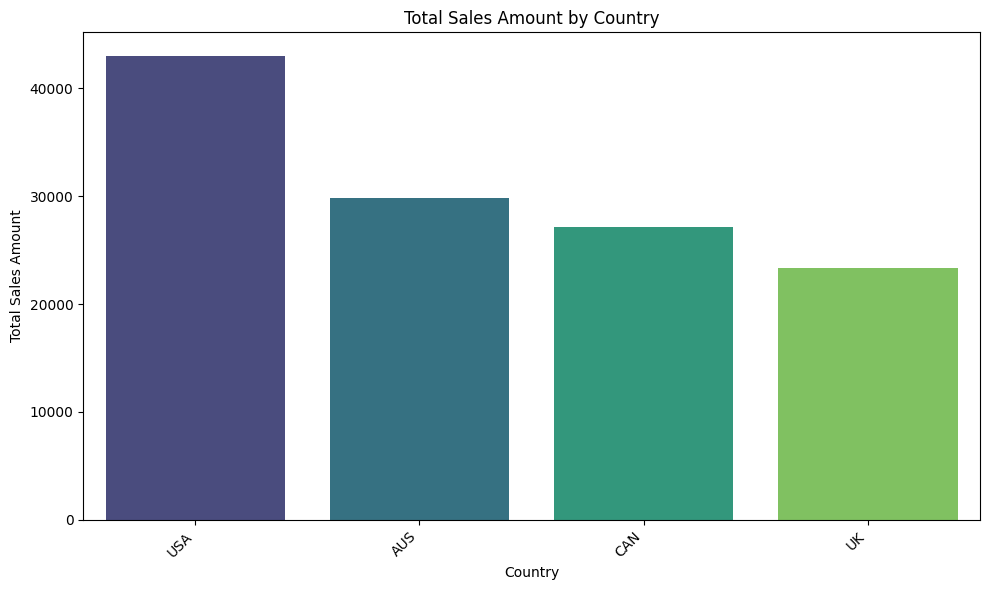

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='total_amount', data=country_sales, palette='viridis')
plt.title('Total Sales Amount by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Product Category Analysis by Country

In [20]:
product_category_by_country = df.groupby(['country', 'product_category']).size().unstack(fill_value=0)
display(product_category_by_country)

product_category,Coffee,Merchandise,Pastry,Sandwich,Smoothie,Tea
country,,,,,,
AUS,1855,110,442,347,198,977
CAN,1898,116,527,353,192,1027
UK,1812,103,503,357,191,975
USA,2739,159,772,542,304,1495


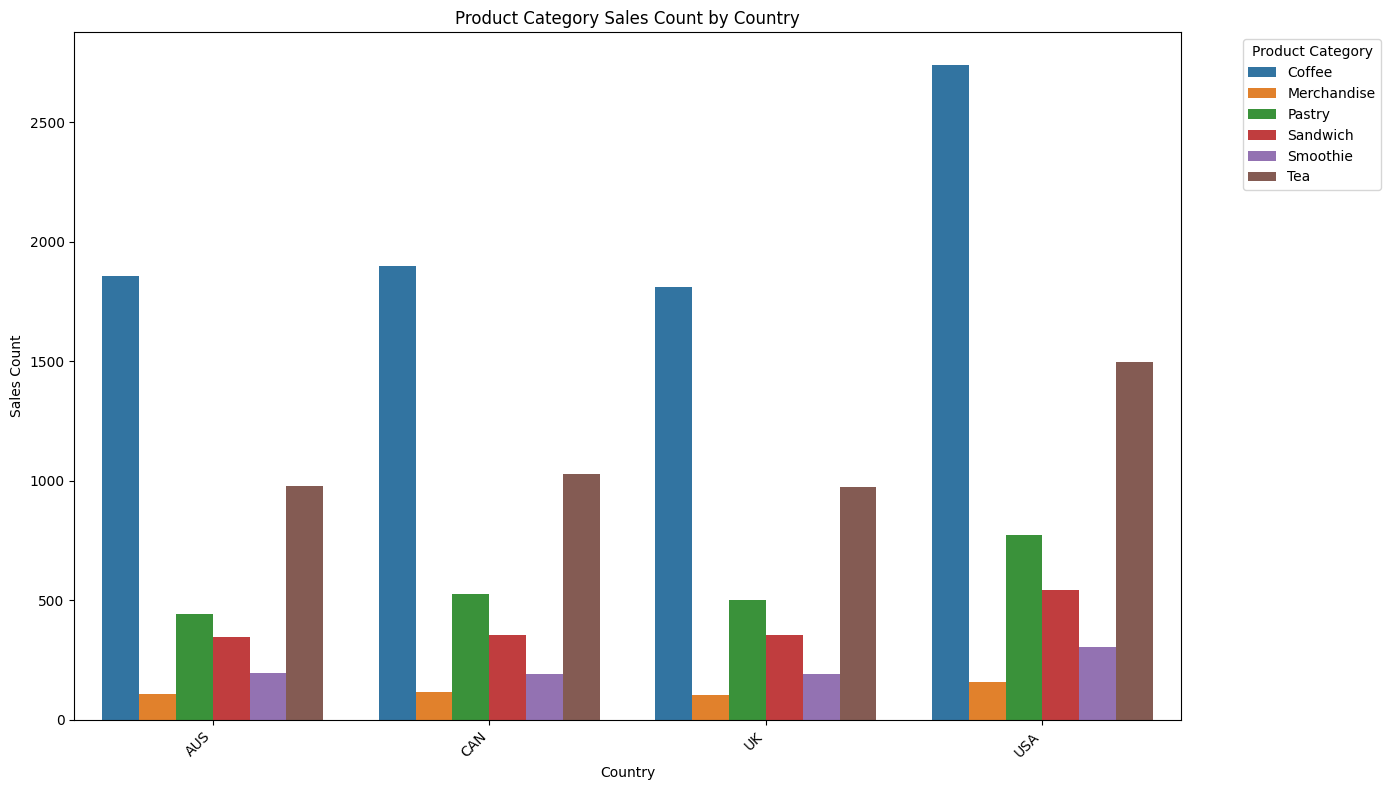

In [23]:
product_category_melted = product_category_by_country.reset_index().melt(id_vars='country', var_name='product_category', value_name='sales_count')

plt.figure(figsize=(14, 8))
sns.barplot(x='country', y='sales_count', hue='product_category', data=product_category_melted, palette='tab10')
plt.title('Product Category Sales Count by Country')
plt.xlabel('Country')
plt.ylabel('Sales Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Gender Distribution Across Countries

In [24]:
gender_distribution = df.groupby(['country', 'customer_gender']).size().unstack(fill_value=0)
display(gender_distribution)

customer_gender,Female,Male,Non-binary,Prefer not to say
country,,,,
AUS,1912,1857,74,86
CAN,1979,1955,84,95
UK,1945,1834,75,87
USA,2833,2930,119,129


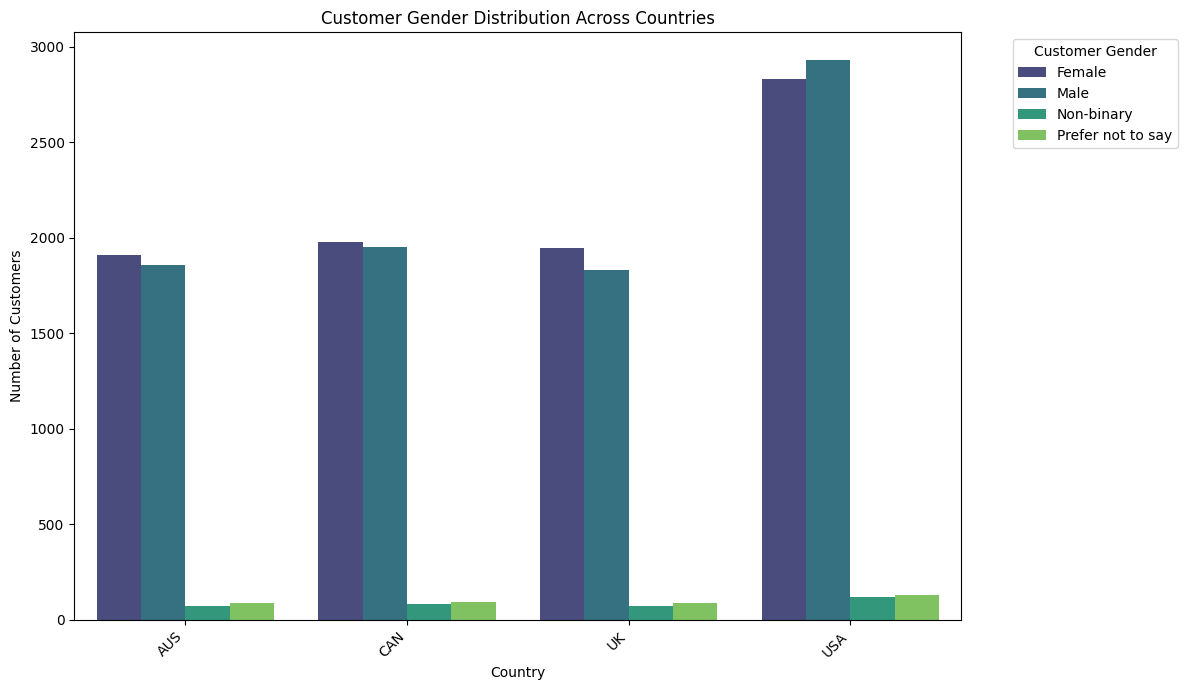

In [25]:
gender_melted = gender_distribution.reset_index().melt(id_vars='country', var_name='customer_gender', value_name='count')

plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='count', hue='customer_gender', data=gender_melted, palette='viridis')
plt.title('Customer Gender Distribution Across Countries')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Purchases Across Age Groups

In [26]:
purchases_by_age_group = df.groupby('customer_age_group')['total_amount'].sum().sort_values(ascending=False).reset_index()
display(purchases_by_age_group)

,customer_age_group,total_amount
0,25-34,35426.56
1,35-44,23039.56
2,55-64,18041.81
3,18-24,17719.90
4,45-54,17328.75
5,65+,11761.73


/tmp/ipykernel_12455/1451876161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_age_group', y='total_amount', data=purchases_by_age_group, palette='magma')


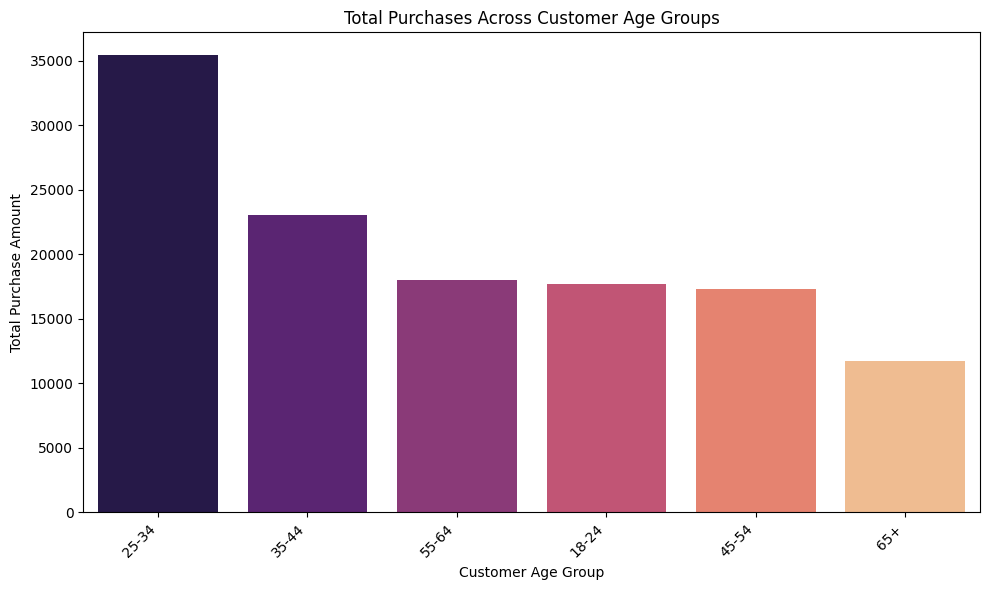

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer_age_group', y='total_amount', data=purchases_by_age_group, palette='magma')
plt.title('Total Purchases Across Customer Age Groups')
plt.xlabel('Customer Age Group')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Category-wise Purchases by Age Group

In [28]:
category_age_group_purchases = df.groupby(['customer_age_group', 'product_category'])['total_amount'].sum().unstack(fill_value=0)
display(category_age_group_purchases)

product_category,Coffee,Merchandise,Pastry,Sandwich,Smoothie,Tea
customer_age_group,,,,,,
18-24,7770.76,1545.83,1338.14,2032.78,1223.77,3808.62
25-34,14957.79,3030.11,2598.60,4911.26,2214.29,7714.51
35-44,9643.29,1969.40,1643.78,3094.06,1688.14,5000.89
45-54,7566.77,1571.61,1203.68,2017.65,1327.57,3641.47
55-64,7522.36,1801.42,1258.55,2361.02,1264.64,3833.82
65+,4841.29,986.04,886.97,1366.39,871.01,2810.03


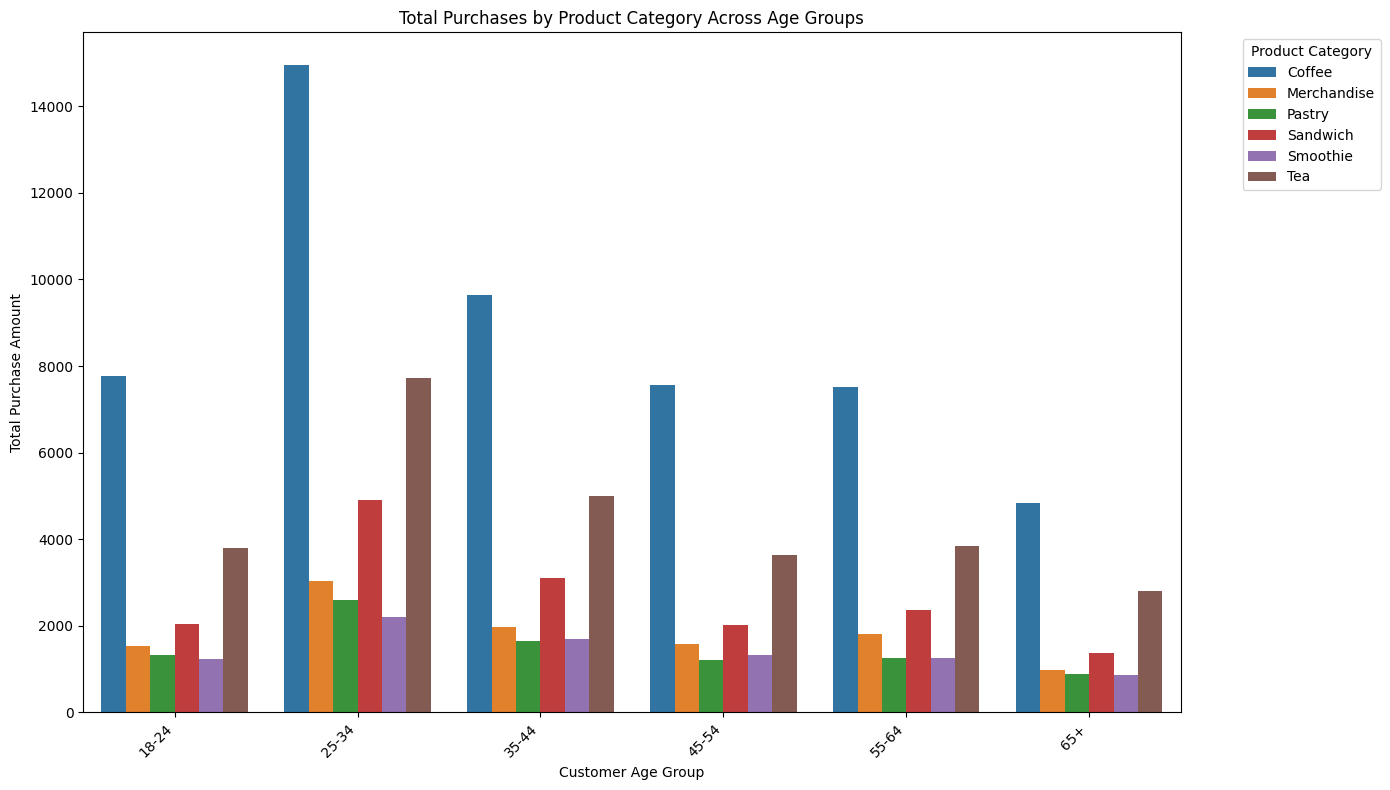

In [29]:
category_age_group_melted = category_age_group_purchases.reset_index().melt(id_vars='customer_age_group', var_name='product_category', value_name='total_amount')

plt.figure(figsize=(14, 8))
sns.barplot(x='customer_age_group', y='total_amount', hue='product_category', data=category_age_group_melted, palette='tab10')
plt.title('Total Purchases by Product Category Across Age Groups')
plt.xlabel('Customer Age Group')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Total Sales of Main Coffee Products by Age Group (Heatmap) - Regenerated

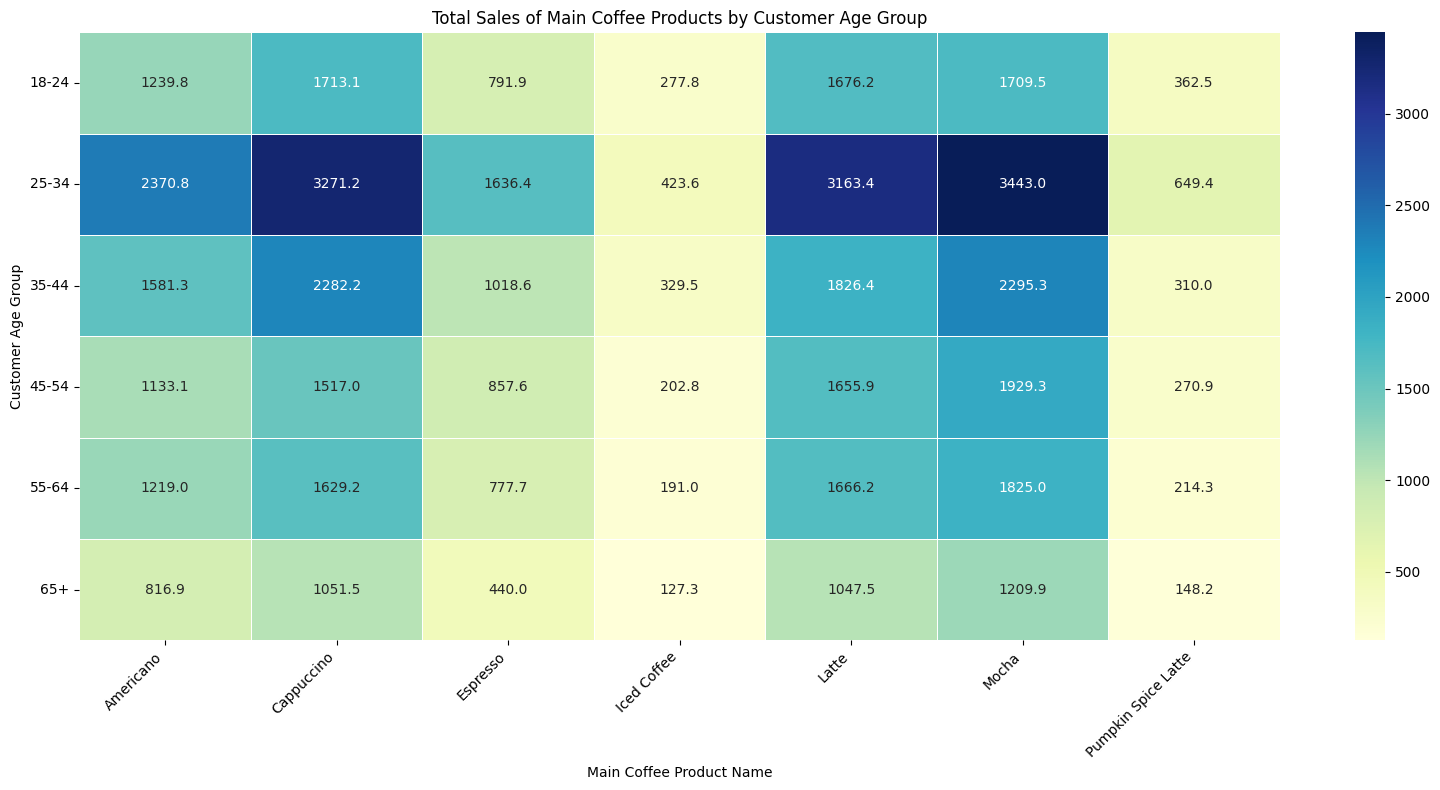

In [48]:
coffee_data = df[df['product_category'] == 'Coffee'].copy()

# Function to extract main product name
def get_main_product_name(product_name):
    product_name = product_name.replace('Small ', '').replace('Medium ', '').replace('Large ', '')
    product_name = product_name.replace('Double ', '').replace('Single ', '')
    return product_name.strip()

coffee_data['main_product_name'] = coffee_data['product_name'].apply(get_main_product_name)

# Group by age group and main product name, summing total amount
main_coffee_sales_by_age = coffee_data.groupby(['customer_age_group', 'main_product_name'])['total_amount'].sum().reset_index()

# Identify top N main coffee products overall based on total sales
top_n = 10 # Adjust as needed for readability
top_main_coffee_products_overall = coffee_data.groupby('main_product_name')['total_amount'].sum().nlargest(top_n).index

# Filter the sales data to include only the top main coffee products
filtered_main_coffee_sales = main_coffee_sales_by_age[main_coffee_sales_by_age['main_product_name'].isin(top_main_coffee_products_overall)]

# Pivot the table for heatmap visualization, with age groups as rows
pivoted_main_coffee_sales_top = filtered_main_coffee_sales.pivot_table(index='customer_age_group', columns='main_product_name', values='total_amount', fill_value=0)

# Sort age groups for better visualization
age_groups_sorted = sorted(pivoted_main_coffee_sales_top.index.unique(), key=lambda x: int(x.split('-')[0]) if x != '65+' else 65)
pivoted_main_coffee_sales_top = pivoted_main_coffee_sales_top.loc[age_groups_sorted]

plt.figure(figsize=(16, 8))
sns.heatmap(pivoted_main_coffee_sales_top, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title(f'Total Sales of Main Coffee Products by Customer Age Group')
plt.xlabel('Main Coffee Product Name')
plt.ylabel('Customer Age Group')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Predictive Modeling: Random Forest for Product Category

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Ensure 'timestamp' is datetime type
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract 'hour' and 'day_of_week'
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Define the target and features
target_rf = 'product_category'
features_rf = [
    'weather_condition',
    'temperature_c',
    'hour',
    'day_of_week',
    'loyalty_member'
]

# Convert boolean 'loyalty_member' to int
df['loyalty_member'] = df['loyalty_member'].astype(int)

# One-hot encode categorical features
categorical_features_rf = ['weather_condition']
X_rf = pd.get_dummies(df[features_rf], columns=categorical_features_rf, drop_first=True)
y_rf = df[target_rf]

# Ensure all columns have a numeric type after one-hot encoding
X_rf = X_rf.astype(float)

# Split the data into training and testing sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

print("Data preparation for Random Forest complete.")
print(f"X_train_rf shape: {X_train_rf.shape}")
print(f"X_test_rf shape: {X_test_rf.shape}")
print(f"y_train_rf shape: {y_train_rf.shape}")
print(f"y_test_rf shape: {y_test_rf.shape}")

Data preparation for Random Forest complete.
X_train_rf shape: (14395, 7)
X_test_rf shape: (3599, 7)
y_train_rf shape: (14395,)
y_test_rf shape: (3599,)


#### Model Training (Random Forest Classifier)

In [66]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using balanced to handle potential class imbalance
rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest model training complete.")

Random Forest model training complete.


#### Model Evaluation (Random Forest Classifier)

In [67]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
report_rf = classification_report(y_test_rf, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.2f}")
print("\nClassification Report:\n")
print(report_rf)

Accuracy: 0.32

Classification Report:

              precision    recall  f1-score   support

      Coffee       0.45      0.54      0.49      1640
 Merchandise       0.00      0.00      0.00        95
      Pastry       0.11      0.10      0.11       436
    Sandwich       0.11      0.08      0.09       328
    Smoothie       0.01      0.01      0.01       194
         Tea       0.25      0.23      0.24       906

    accuracy                           0.32      3599
   macro avg       0.16      0.16      0.16      3599
weighted avg       0.30      0.32      0.31      3599



#### Feature Importance

In [68]:
# Get feature importances from the Random Forest model
feature_importances_rf = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
display(feature_importances_rf.sort_values(by='Importance', ascending=False))

,Feature,Importance
0,temperature_c,0.589151
1,hour,0.269435
2,day_of_week,0.100739
3,loyalty_member,0.016292
6,weather_condition_Sunny,0.011514
4,weather_condition_Rainy,0.010975
5,weather_condition_Snowy,0.001895


### Purchase Frequency: Loyalty Member vs. Non-Loyalty Member

In [84]:
df.groupby('loyalty_member')['total_amount'].mean()

,total_amount
loyalty_member,
0,6.981736
1,6.567422


In [85]:
df.groupby('loyalty_member')['quantity'].mean()

,quantity
loyalty_member,
0,1.723421
1,1.692542


In [86]:
df.groupby('loyalty_member')['high_value_order'].mean()

,high_value_order
loyalty_member,
0,0.052271
1,0.044640


In [87]:
df.groupby(['loyalty_member','product_category'])['quantity'].sum()

loyalty_member  product_category
0               Coffee              9808
                Merchandise          611
                Pastry              2662
                Sandwich            1947
                Smoothie            1073
                Tea                 5297
1               Coffee              4456
                Merchandise          226
                Pastry              1179
                Sandwich             805
                Smoothie             444
                Tea                 2331
Name: quantity, dtype: int64

### Product Category Sales Across Months

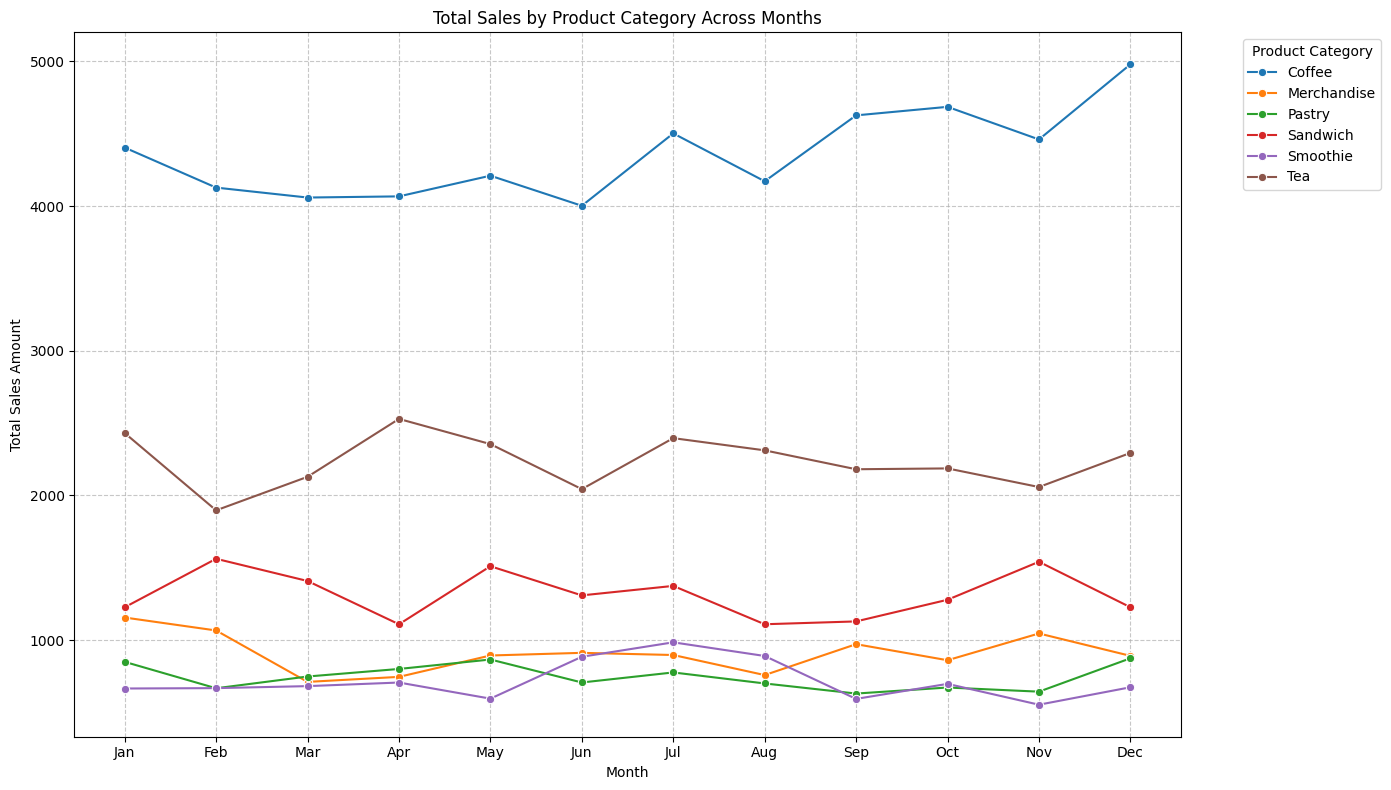

In [88]:
df['month'] = df['timestamp'].dt.month
monthly_category_sales = df.groupby(['month', 'product_category'])['total_amount'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(x='month', y='total_amount', hue='product_category', data=monthly_category_sales, marker='o')
plt.title('Total Sales by Product Category Across Months')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [94]:
summary = f"""
Coffee Shop Data Summary

Monthly Sales:
{df.groupby(df['timestamp'].dt.month)['total_amount'].sum().to_string()}

Country-wise Sales:
{df.groupby('country')['total_amount'].sum().sort_values(ascending=False).to_string()}

Product Category Sales:
{df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False).to_string()}

Loyalty vs Non-Loyal:
{df.groupby('loyalty_member')['total_amount'].mean().to_string()}

Top Products:
{df.groupby('product_name')['total_amount'].sum().sort_values(ascending=False).head(10).to_string()}
"""

In [91]:
insights = """
Coffee Shop Sales Insights

Overall Summary:
This analysis explores coffee shop sales data using data cleaning, exploratory analysis, and predictive modeling to uncover customer behavior, product trends, and key business drivers.

1. Data Quality & Preparation:
The dataset was cleaned by handling missing values and removing non-informative variables. Additional features such as hour, day of week, high-value transactions, and cold drink indicators were engineered to enhance analysis.

2. Key Business Insights:

- Regional Performance:
The USA leads in total sales, followed by Australia, Canada, and the UK, indicating strong regional demand and potential for targeted expansion strategies.

- Product Dominance:
Coffee is the primary revenue driver across all regions and customer segments. Other categories such as tea, pastry, and sandwiches act as complementary offerings rather than core drivers.

- Customer Demographics:
The 25–34 age group contributes the highest sales volume, making it the most valuable segment for targeted marketing. Gender distribution is relatively balanced, suggesting gender-neutral strategies.

- Loyalty Behavior:
Loyal customers do not generate higher transaction value. In fact, they spend slightly less per order, purchase slightly fewer items, and are less likely to place high-value orders compared to non-loyal customers.
This suggests that loyalty programs currently drive engagement rather than increasing basket size.

- Product Preferences:
Customer preferences remain largely consistent across segments, with coffee and tea dominating. Loyalty status does not significantly influence product choice.

- Seasonal:
Coffee sales show a clear upward trend in the second half of the year, peaking in December, indicating strong seasonal demand likely driven by colder weather and holiday consumption patterns.
Tea and sandwich sales remain relatively stable throughout the year with minor fluctuations, indicating consistent baseline demand and making them reliable supporting revenue streams.
Smoothie sales tend to dip in later months compared to mid-year peaks, suggesting sensitivity to seasonal changes and higher demand during warmer periods.

-
3. Behavioral Insights:

- Purchase behavior appears to be driven more by situational and contextual factors (such as time and environment) rather than demographic attributes.
- Customers tend to make small, routine purchases rather than large bulk transactions.
- High-value transactions are primarily driven by higher quantities and premium-priced items.

4. Predictive Modeling Insights:

- Random Forest Model:
Product category prediction shows that temperature and time of day are the strongest drivers of product choice.
The model performs significantly better than random guessing, confirming meaningful behavioral patterns, but is limited by class imbalance.

5. Additional Key Observations (Added Insights):

- Temperature vs Product Choice:
Higher temperatures increase the likelihood of cold (iced) beverage purchases, highlighting an opportunity for dynamic, weather-based marketing strategies.

- Loyalty Program Effectiveness:
The current loyalty program does not significantly increase transaction value, suggesting a need to redesign incentives toward bundle offers or upselling strategies.

- Basket Size Opportunity:
Since most customers purchase only 1–2 items per transaction, there is strong potential to increase revenue through combo deals and cross-selling.

- Model Limitations:
Certain analyses (such as customer frequency) are limited due to lack of repeat customer tracking, indicating opportunities for richer data collection in future systems.

6. Recommendations:

- Introduce bundle offers to increase basket size, especially for loyalty members.
- Implement weather-based promotions .
- Focus marketing efforts on the 25–34 age group.
- Promote high-margin items during peak hours.
- Redesign loyalty programs to incentivize higher spending per transaction rather than just repeat visits.

"""

In [92]:
with open("insights.txt", "w") as f:
    f.write(insights)

In [93]:
from google.colab import files
files.download("insights.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
with open("data_summary.txt", "w") as f:
    f.write(summary)

In [96]:
from google.colab import files
files.download("data_summary.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>